<h1 style='color: blue; font-size: 34px; font-weight: bold;'> Modelo de Detecção de Fraude em Cartão de Crédito</h1>

<p style='font-size: 18px; line-height: 1.8; text-align: justify;'>
Este projeto desenvolve um modelo de priorização de transações fraudulentas usando a base simulada Sparkov. A solução separa <b>modelo</b>, <b>calibração</b> e <b>política de decisão</b>, respeitando a ordem temporal dos eventos.
</p>

> A especificação metodológica completa está em `PROJETO_NOVA_BASE.md`. A base é simulada; os resultados servem para estudo e não devem ser interpretados como garantia de desempenho em produção.

# <font color='orange' style='font-size: 40px;'> Library e Funções </font>
<hr style='border: 2px solid orange;'>

In [74]:
from pathlib import Path
from datetime import date
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

from IPython.display import display
from hyperopt import hp, tpe, fmin, Trials, STATUS_OK
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.frozen import FrozenEstimator
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, confusion_matrix, brier_score_loss,
                             log_loss, precision_recall_curve)
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
Path('models').mkdir(exist_ok=True)


In [75]:
def plota_barras(variavel, df, titulo, top_n=None, rotation=0):
    contagem = df[variavel].value_counts(dropna=False).head(top_n)
    ax = contagem.plot.bar(color='#1FB3E5', title=titulo)
    ax.set_ylabel('Quantidade')
    ax.tick_params(axis='x', rotation=rotation)
    for barra, valor in zip(ax.patches, contagem.values):
        ax.annotate(f'{valor/contagem.sum():.1%}',
                    (barra.get_x()+barra.get_width()/2, barra.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout(); plt.show()


def analisa_distribuicao_via_percentis(df, variaveis):
    return df[variaveis].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T


def taxa_por_grupo(df, coluna, target='is_fraud', top_n=20):
    tabela = (df.groupby(coluna, observed=True)[target]
              .agg(qtd='size', fraudes='sum', taxa_fraude='mean')
              .sort_values(['taxa_fraude','qtd'], ascending=False))
    return tabela.head(top_n)




In [76]:
def haversine_km(lat1, lon1, lat2, lon2):
    # Distância do arco entre dois pontos da Terra.
    raio_terra = 6371.0088
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2-lat1, lon2-lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*raio_terra*np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def media_std_historica(df, grupo, valor, prefixo):
    # Estatísticas acumuladas excluindo a observação atual.
    g = df.groupby(grupo, sort=False, observed=True)[valor]
    n = df.groupby(grupo, sort=False, observed=True).cumcount().astype('float32')
    soma = g.cumsum() - df[valor]
    soma2 = df.assign(_quadrado=df[valor]**2).groupby(grupo, sort=False, observed=True)['_quadrado'].cumsum() - df[valor]**2
    media = soma / n.replace(0, np.nan)
    variancia = (soma2 / n.replace(0, np.nan) - media**2).clip(lower=0)
    df[f'media_{prefixo}'] = media.fillna(0).astype('float32')
    df[f'std_{prefixo}'] = np.sqrt(variancia).fillna(0).astype('float32')
    return df


In [77]:
def cria_features(df):
    d = df.sort_values(['trans_date_trans_time','trans_num']).reset_index(drop=True).copy()

    # Transação, tempo e geografia.
    d['log_amt'] = np.log1p(d.amt).astype('float32')
    d['hora'] = d.trans_date_trans_time.dt.hour.astype('int8')
    d['dia_semana'] = d.trans_date_trans_time.dt.dayofweek.astype('int8')
    d['fim_semana'] = (d.dia_semana >= 5).astype('int8')
    d['hora_sin'] = np.sin(2*np.pi*d.hora/24).astype('float32')
    d['hora_cos'] = np.cos(2*np.pi*d.hora/24).astype('float32')
    d['idade'] = ((d.trans_date_trans_time.dt.normalize() - d.dob).dt.days / 365.25).astype('float32')
    d['distancia_cliente_lojista_km'] = haversine_km(d.lat, d.long, d.merch_lat, d.merch_long).astype('float32')

    # Histórico causal do cartão.
    g_cartao = d.groupby('cc_num', sort=False, observed=True)
    d['qtd_transacoes_cartao_hist'] = g_cartao.cumcount().astype('int32')
    d['segundos_ultima_transacao'] = g_cartao.trans_date_trans_time.diff().dt.total_seconds().fillna(-1).clip(-1, 30*86400).astype('float32')
    d = media_std_historica(d, 'cc_num', 'amt', 'amt_cartao_hist')
    d['zscore_amt_cartao'] = ((d.amt-d.media_amt_cartao_hist) / d.std_amt_cartao_hist.replace(0, np.nan)).replace([np.inf,-np.inf], np.nan).fillna(0).clip(-20,20).astype('float32')
    primeiro_cartao = g_cartao.trans_date_trans_time.transform('min')
    dias_relacionamento = (d.trans_date_trans_time-primeiro_cartao).dt.total_seconds()/86400
    d['freq_transacoes_cartao_dia'] = (d.qtd_transacoes_cartao_hist / np.maximum(dias_relacionamento, 1)).astype('float32')

    # Histórico causal do lojista.
    g_lojista = d.groupby('merchant', sort=False, observed=True)
    d['qtd_transacoes_lojista_hist'] = g_lojista.cumcount().astype('int32')
    d = media_std_historica(d, 'merchant', 'amt', 'amt_lojista_hist')

    # Grafo bipartido cartão -> lojista.
    d['qtd_transacoes_par_hist'] = d.groupby(['cc_num','merchant'], sort=False, observed=True).cumcount().astype('int16')
    primeira_aresta = d.qtd_transacoes_par_hist.eq(0).astype('int8')
    d['grau_cartao_hist'] = (primeira_aresta.groupby(d.cc_num, sort=False).cumsum()-primeira_aresta).astype('int16')
    d['grau_lojista_hist'] = (primeira_aresta.groupby(d.merchant, sort=False).cumsum()-primeira_aresta).astype('int16')
    d['novo_par_cartao_lojista'] = primeira_aresta
    d['participacao_lojista_cartao'] = (d.qtd_transacoes_par_hist / d.qtd_transacoes_cartao_hist.replace(0, np.nan)).fillna(0).astype('float32')

    return d


In [78]:
def metricas_modelo(nome, etapa, y_true, proba, cutoff=None):
    auc = roc_auc_score(y_true, proba)
    resultado = {
        'Modelo': nome, 'Etapa': etapa,
        'Gini': 2*auc-1,
        'PR_AUC': average_precision_score(y_true, proba),
        'Taxa_Fraude': np.mean(y_true)
    }
    if cutoff is not None:
        pred = (np.asarray(proba) >= cutoff).astype(int)
        resultado.update({
            'Cutoff': cutoff,
            'Precisao': precision_score(y_true, pred, zero_division=0),
            'Recall': recall_score(y_true, pred, zero_division=0),
            'F1': f1_score(y_true, pred, zero_division=0),
            'Alert_Rate': pred.mean()
        })
    return pd.DataFrame([resultado])


def tabela_capacidade(y_true, proba, capacidades=(.001,.0025,.005,.01,.02)):
    aux = pd.DataFrame({'y':np.asarray(y_true), 'p':np.asarray(proba)}).sort_values('p', ascending=False)
    linhas = []
    for cap in capacidades:
        n = max(1, int(np.ceil(len(aux)*cap)))
        fila = aux.head(n)
        linhas.append({'Capacidade':cap, 'Alertas':n, 'Precisao':fila.y.mean(),
                       'Recall':fila.y.sum()/max(aux.y.sum(),1), 'Cutoff_Score':fila.p.min()})
    return pd.DataFrame(linhas)


In [79]:
def modelo_lightgbm(parametros=None):
    base = dict(
        objective='binary', n_estimators=225, learning_rate=.035,
        num_leaves=12, max_depth=4, min_child_samples=250,
        subsample=.8, colsample_bytree=.8, reg_alpha=2,
        reg_lambda=5, subsample_freq=1, random_state=RANDOM_STATE, n_jobs=-1,
        verbosity=-1
    )
    if parametros: base.update(parametros)
    return LGBMClassifier(**base)


def otimizacao_hyperopt(x_train, y_train, x_valid, y_valid, max_evals=20):
    espaco = {
        'n_estimators': hp.quniform('n_estimators', 100, 350, 25),
        'learning_rate': hp.loguniform('learning_rate', np.log(.015), np.log(.08)),
        'num_leaves': hp.quniform('num_leaves', 7, 21, 2),
        'max_depth': hp.quniform('max_depth', 3, 5, 1),
        'min_child_samples': hp.quniform('min_child_samples', 150, 600, 50),
        'subsample': hp.uniform('subsample', .65, 1),
        'colsample_bytree': hp.uniform('colsample_bytree', .6, 1),
        'reg_alpha': hp.loguniform('reg_alpha', np.log(.1), np.log(20)),
        'reg_lambda': hp.loguniform('reg_lambda', np.log(.5), np.log(30))}

    inteiros = ['n_estimators','num_leaves','max_depth','min_child_samples']
    def converte(p):
        p = p.copy()
        for c in inteiros: p[c] = int(p[c])
        return p

    def objetivo(p):
        p = converte(p)
        m = modelo_lightgbm(p).fit(x_train, y_train, categorical_feature='auto')
        pt, pv = m.predict_proba(x_train)[:,1], m.predict_proba(x_valid)[:,1]
        ap_valid = average_precision_score(y_valid, pv)
        ap_train = average_precision_score(y_train, pt)
        gini_train = 2*roc_auc_score(y_train, pt)-1
        gini_valid = 2*roc_auc_score(y_valid, pv)-1
        gap_excessivo = max(0, gini_train-gini_valid-.05)
        gap_ap_excessivo = max(0, ap_train-ap_valid-.08)
        # PR-AUC evidencia memorização que pode ficar escondida no Gini saturado.
        perda = -ap_valid + .25*gap_excessivo + .75*gap_ap_excessivo
        return {'loss':perda, 'status':STATUS_OK, 'ap_valid':ap_valid,
                'ap_train':ap_train, 'gap_ap':ap_train-ap_valid,
                'gini_train':gini_train, 'gini_valid':gini_valid}

    trials = Trials()
    best = fmin(objetivo, espaco, algo=tpe.suggest, max_evals=max_evals,
                trials=trials, rstate=np.random.default_rng(RANDOM_STATE), show_progressbar=True)
    best = converte(best)
    modelo = modelo_lightgbm(best).fit(x_train, y_train, categorical_feature='auto')
    return modelo, best, trials


In [80]:
def cria_rating(score, cortes):
    return pd.cut(score, bins=[-np.inf]+list(cortes)+[np.inf],
                  labels=['A','B','C','D','E'], include_lowest=True)


def ajusta_calibrador_score(score, y, metodo):
    if metodo == 'isotonic':
        modelo = IsotonicRegression(out_of_bounds='clip').fit(score, y)
    else:
        modelo = LogisticRegression(C=1, random_state=RANDOM_STATE).fit(
            np.asarray(score).reshape(-1,1), y)
    return modelo


def prediz_calibrador(modelo, score, metodo):
    if metodo == 'isotonic':
        return modelo.predict(score)
    return modelo.predict_proba(np.asarray(score).reshape(-1,1))[:,1]


In [81]:
def retorno_financeiro_incremental(df, pred, taxa_recuperacao=.75,
                                   custo_revisao=2, custo_atrito_fp=5):
    pred = np.asarray(pred).astype(bool)
    fraude = df.is_fraud.to_numpy().astype(bool)
    valores = df.amt.to_numpy()
    tp, fp = pred & fraude, pred & ~fraude
    perda_sem_modelo = valores[fraude].sum()
    perda_residual = valores[fraude & ~pred].sum() + (1-taxa_recuperacao)*valores[tp].sum()
    custo_operacional = pred.sum()*custo_revisao + fp.sum()*custo_atrito_fp
    retorno_incremental = perda_sem_modelo-perda_residual-custo_operacional
    return {'Perda_sem_modelo':perda_sem_modelo,
            'Fraude_evitada':taxa_recuperacao*valores[tp].sum(),
            'Custo_revisao_atrito':custo_operacional,
            'Retorno_incremental':retorno_incremental}


def escolhe_cutoff_politica(df_politica, score, capacidade_max=.01,
                            taxa_recuperacao=.75, custo_revisao=2, custo_atrito_fp=5):
    aux = df_politica[['is_fraud','amt']].copy()
    aux['score'] = np.asarray(score)
    candidatos = np.unique(np.quantile(score, np.linspace(.90, .9999, 600)))
    linhas = []
    for cutoff in candidatos:
        pred = aux.score >= cutoff
        financeiro = retorno_financeiro_incremental(
            aux, pred, taxa_recuperacao, custo_revisao, custo_atrito_fp)
        linhas.append({'cutoff':cutoff, 'alert_rate':pred.mean(),
                       'precision':precision_score(aux.is_fraud,pred,zero_division=0),
                       'recall':recall_score(aux.is_fraud,pred,zero_division=0),
                       'retorno_incremental':financeiro['Retorno_incremental']})
    curva = pd.DataFrame(linhas)
    elegiveis = curva[curva.alert_rate <= capacidade_max]
    melhor = elegiveis.sort_values(['retorno_incremental','precision'], ascending=False).iloc[0]
    return float(melhor.cutoff), curva


In [82]:
def metricas_mensais(df, score, cutoff):
    aux = df[['trans_date_trans_time','is_fraud']].copy()
    aux['score'] = np.asarray(score)
    aux['mes'] = aux.trans_date_trans_time.dt.to_period('M').astype(str)
    linhas = []
    for mes, d in aux.groupby('mes'):
        pred = d.score >= cutoff
        auc = roc_auc_score(d.is_fraud, d.score)
        linhas.append({'Mes':mes, 'N':len(d), 'Taxa_Fraude':d.is_fraud.mean(),
                       'Gini':2*auc-1, 'PR_AUC':average_precision_score(d.is_fraud,d.score),
                       'Precisao':precision_score(d.is_fraud,pred,zero_division=0),
                       'Recall':recall_score(d.is_fraud,pred,zero_division=0),
                       'Alert_Rate':pred.mean()})
    return pd.DataFrame(linhas)


def plot_shap(modelo, x_amostra, titulo):
    explainer = shap.TreeExplainer(modelo)
    valores = explainer(x_amostra)
    shap.plots.beeswarm(valores, max_display=20, show=False)
    plt.title(titulo); plt.tight_layout(); plt.show()
    return explainer, valores


# <font color='orange' style='font-size: 40px;'> 1. Leitura do Dataset </font>
<hr style='border: 2px solid orange;'>

Os dois arquivos são partes consecutivas da mesma simulação. Eles serão concatenados para ordenar os eventos e criar históricos causais. A separação de desenvolvimento continuará sendo temporal; concatenar não autoriza usar o futuro.

In [83]:
df_train_original = pd.read_csv('./data/fraudTrain.csv')
df_test_original = pd.read_csv('./data/fraudTest.csv')
df_train_original['arquivo_origem'] = 'fraudTrain'
df_test_original['arquivo_origem'] = 'fraudTest'

df_raw = pd.concat([df_train_original, df_test_original], ignore_index=True)
df_raw = df_raw.drop(columns=[c for c in df_raw.columns if c.lower().startswith('unnamed')])
df_raw['trans_date_trans_time'] = pd.to_datetime(df_raw.trans_date_trans_time)
df_raw['dob'] = pd.to_datetime(df_raw.dob)
df_raw = df_raw.sort_values('trans_date_trans_time').reset_index(drop=True)
print(f'{len(df_raw):,} transações | {df_raw.is_fraud.sum():,} fraudes | taxa={df_raw.is_fraud.mean():.3%}')
display(df_raw.head(3))


1,852,394 transações | 9,651 fraudes | taxa=0.521%


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,arquivo_origem
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0,fraudTrain
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0,fraudTrain
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0,fraudTrain


In [84]:
auditoria = pd.DataFrame({
    'dtype':df_raw.dtypes.astype(str),
    'nulos':df_raw.isna().sum(),
    'pct_nulos':df_raw.isna().mean(),
    'unicos':df_raw.nunique(dropna=False)})
display(auditoria)
print('Transações duplicadas:', df_raw.trans_num.duplicated().sum())
print('Período:', df_raw.trans_date_trans_time.min(), 'até', df_raw.trans_date_trans_time.max())


,dtype,nulos,pct_nulos,unicos
trans_date_trans_time,datetime64[us],0,0.0000,1819551
cc_num,int64,0,0.0000,999
merchant,str,0,0.0000,693
category,str,0,0.0000,14
amt,float64,0,0.0000,60616
first,str,0,0.0000,355
last,str,0,0.0000,486
gender,str,0,0.0000,2
street,str,0,0.0000,999
city,str,0,0.0000,906


Transações duplicadas: 0
Período: 2019-01-01 00:00:18 até 2020-12-31 23:59:34


# <font color='orange' style='font-size: 40px;'> 2. Análise da Target </font>
<hr style='border: 2px solid orange;'>

# <font color='green' style='font-size: 30px;'> 2.1) Target `is_fraud` </font>
<hr style='border: 2px solid green;'>

A target é observada diretamente: `1` representa fraude e `0`, transação legítima.

Como menos de 1% das transações são fraude, um modelo que sempre respondesse “legítima” teria mais de 99% de acurácia e nenhuma utilidade. Por isso, as métricas principais serão Gini, PR-AUC, precision e recall.

,qtd,percentual
is_fraud,,
0,1842743,0.9948
1,9651,0.0052


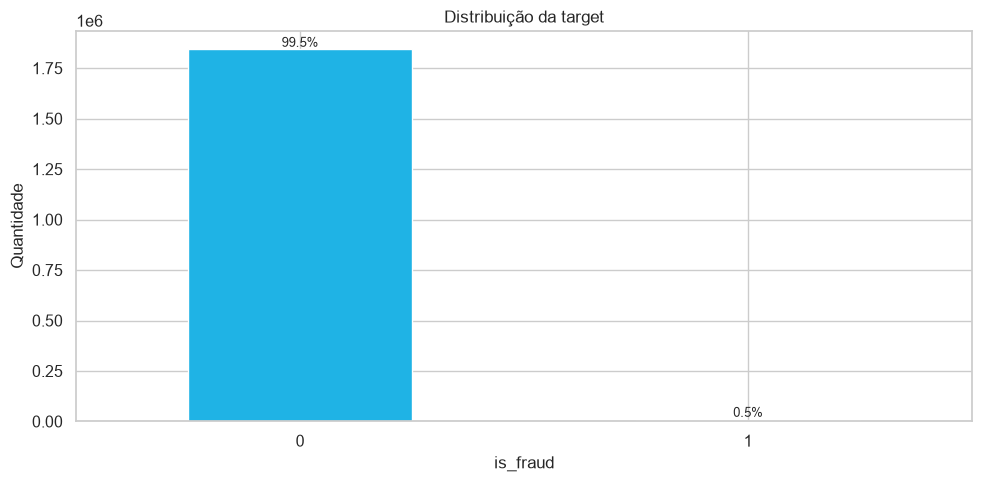

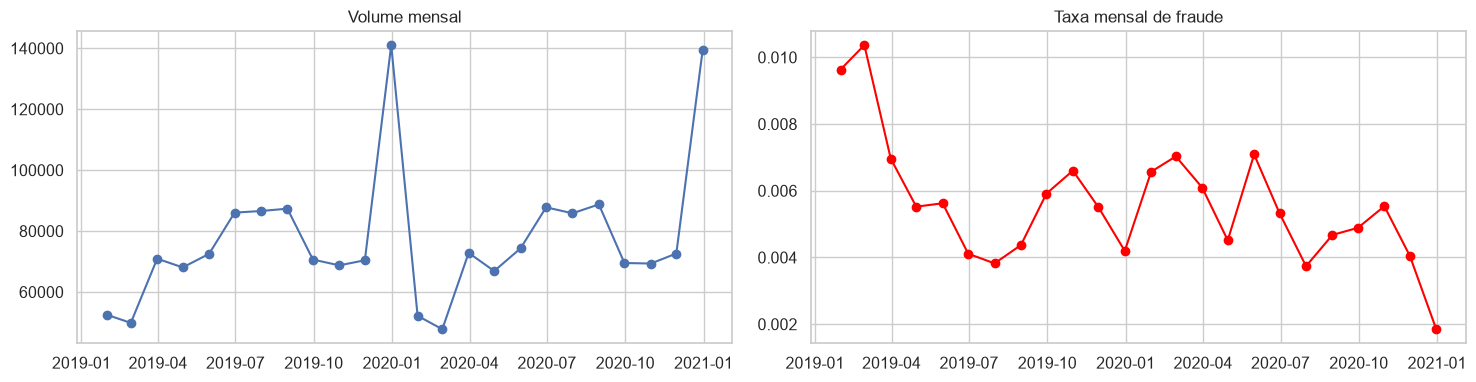

,trans_date_trans_time,qtd,fraudes,taxa_fraude
0,2019-01-31,52525,506,0.0096
1,2019-02-28,49866,517,0.0104
2,2019-03-31,70939,494,0.0070
3,2019-04-30,68078,376,0.0055
4,2019-05-31,72532,408,0.0056
5,2019-06-30,86064,354,0.0041
6,2019-07-31,86596,331,0.0038
7,2019-08-31,87359,382,0.0044
8,2019-09-30,70652,418,0.0059
9,2019-10-31,68758,454,0.0066


In [85]:
display(df_raw.is_fraud.value_counts().rename_axis('is_fraud').to_frame('qtd').assign(
    percentual=lambda d: d.qtd/d.qtd.sum()))
plota_barras('is_fraud', df_raw, 'Distribuição da target')

target_mensal = (df_raw.set_index('trans_date_trans_time').resample('ME').is_fraud
                  .agg(qtd='size', fraudes='sum', taxa_fraude='mean').reset_index())
fig, ax = plt.subplots(1,2,figsize=(15,4))
ax[0].plot(target_mensal.trans_date_trans_time, target_mensal.qtd, marker='o'); ax[0].set_title('Volume mensal')
ax[1].plot(target_mensal.trans_date_trans_time, target_mensal.taxa_fraude, marker='o', color='red'); ax[1].set_title('Taxa mensal de fraude')
plt.tight_layout(); plt.show()
display(target_mensal)


# <font color='green' style='font-size: 30px;'> 2.2) Separação Temporal </font>
<hr style='border: 2px solid green;'>

Cada decisão possui seu próprio período:

- **Treino:** aprende os padrões.
- **Validação:** escolhe hiperparâmetros e mede overfitting.
- **Calibração:** ajusta a escala das probabilidades; abril treina e maio compara os métodos.
- **Política:** junho escolhe o cutoff.
- **Teste e OOT:** medem generalização sem interferir nas escolhas.

In [86]:
def define_amostra(data):
    return np.select([
        data < pd.Timestamp('2020-01-01'),
        data < pd.Timestamp('2020-04-01'),
        data < pd.Timestamp('2020-06-01'),
        data < pd.Timestamp('2020-06-21 12:14:00'),
        data < pd.Timestamp('2020-10-01')],
        ['Treino','Validacao','Calibracao','Politica','Teste'], default='OOT')

df_raw['amostra'] = define_amostra(df_raw.trans_date_trans_time)
resumo_amostras = df_raw.groupby('amostra').is_fraud.agg(qtd='size', fraudes='sum', taxa_fraude='mean')
display(resumo_amostras.reindex(['Treino','Validacao','Calibracao','Politica','Teste','OOT']))


,qtd,fraudes,taxa_fraude
amostra,,,
Treino,924850,5220,0.0056
Validacao,172843,1123,0.0065
Calibracao,141235,829,0.0059
Politica,57747,334,0.0058
Teste,274198,1209,0.0044
OOT,281521,936,0.0033


# <font color='orange' style='font-size: 40px;'> 3. Análise Exploratória </font>
<hr style='border: 2px solid orange;'>

A EDA inferencial será concentrada no treino. Teste e OOT não devem orientar decisões de feature engineering.

# <font color='green' style='font-size: 30px;'> 3.1) Qualidade e Variáveis Numéricas </font>
<hr style='border: 2px solid green;'>

In [87]:
df_eda = df_raw.loc[df_raw.amostra.eq('Treino')].copy()
df_eda['idade'] = (df_eda.trans_date_trans_time-df_eda.dob).dt.days/365.25
df_eda['distancia_km'] = haversine_km(df_eda.lat,df_eda.long,df_eda.merch_lat,df_eda.merch_long)
display(analisa_distribuicao_via_percentis(df_eda, ['amt','idade','city_pop','distancia_km']))
display(df_eda.groupby('is_fraud')[['amt','idade','city_pop','distancia_km']].median().T)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
amt,"924,850.0000",70.2654,161.7134,1.0000,1.2600,2.4400,9.6300,47.4000,83.0200,195.9500,544.6102,"28,948.9000"
idade,"924,850.0000",45.8425,17.3713,13.9220,16.6461,21.6427,32.4298,43.8001,56.9473,79.3593,91.1732,95.1650
city_pop,"924,850.0000","89,144.8009","302,552.6733",23.0000,53.0000,139.0000,743.0000,"2,456.0000","20,478.0000","525,713.0000","1,577,385.0000","2,906,700.0000"
distancia_km,"924,850.0000",76.1257,29.1117,0.0223,11.0890,24.7425,55.3570,78.2377,98.5118,120.4960,132.0724,150.8346


is_fraud,0,1
amt,47.1800,390.8750
idade,43.7864,47.3018
city_pop,"2,456.0000","2,526.0000"
distancia_km,78.2377,78.2109


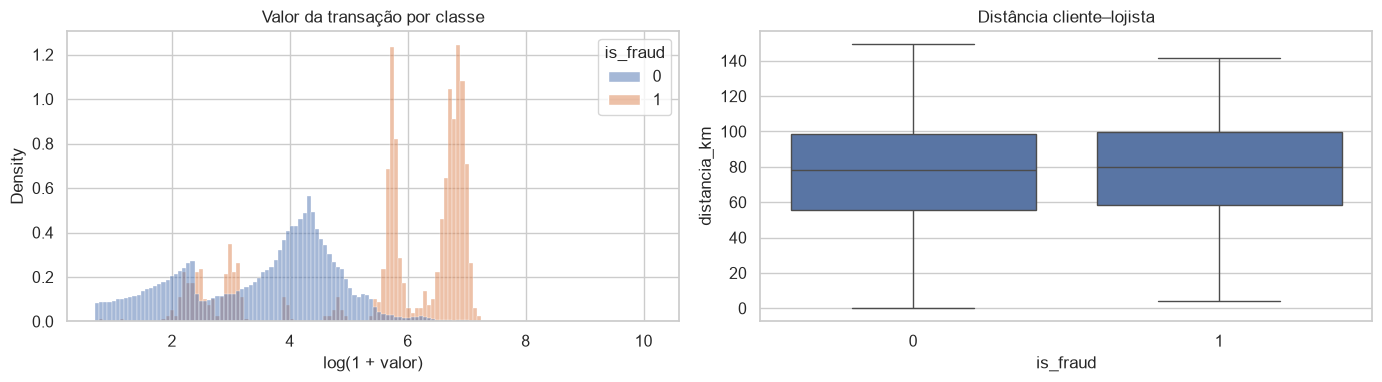

In [88]:
amostra_plot = df_eda.sample(min(200000,len(df_eda)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(1,2,figsize=(14,4))
sns.histplot(data=amostra_plot, x=np.log1p(amostra_plot.amt), hue='is_fraud', stat='density', common_norm=False, ax=ax[0])
ax[0].set_xlabel('log(1 + valor)'); ax[0].set_title('Valor da transação por classe')
sns.boxplot(data=amostra_plot, x='is_fraud', y='distancia_km', showfliers=False, ax=ax[1])
ax[1].set_title('Distância cliente–lojista')
plt.tight_layout(); plt.show()


# <font color='green' style='font-size: 30px;'> 3.2) Variáveis Categóricas </font>
<hr style='border: 2px solid green;'>

Taxa sem volume pode enganar. Toda comparação mostra simultaneamente quantidade de transações, fraudes e taxa.

In [89]:
display(taxa_por_grupo(df_eda, 'category', top_n=20))
display(taxa_por_grupo(df_eda, 'state', top_n=15))


,qtd,fraudes,taxa_fraude
category,,,
shopping_net,69554,1201,0.0173
misc_net,45040,629,0.0140
grocery_pos,87893,1202,0.0137
shopping_pos,83205,583,0.0070
gas_transport,93859,439,0.0047
misc_pos,56879,170,0.0030
travel,29011,86,0.0030
grocery_net,32320,94,0.0029
entertainment,67097,163,0.0024


,qtd,fraudes,taxa_fraude
state,,,
DE,9,9,1.0000
RI,390,15,0.0385
AK,1520,27,0.0178
NV,3984,37,0.0093
TN,12421,104,0.0084
NH,5888,49,0.0083
DC,2617,21,0.0080
CO,9853,79,0.0080
NY,59498,454,0.0076


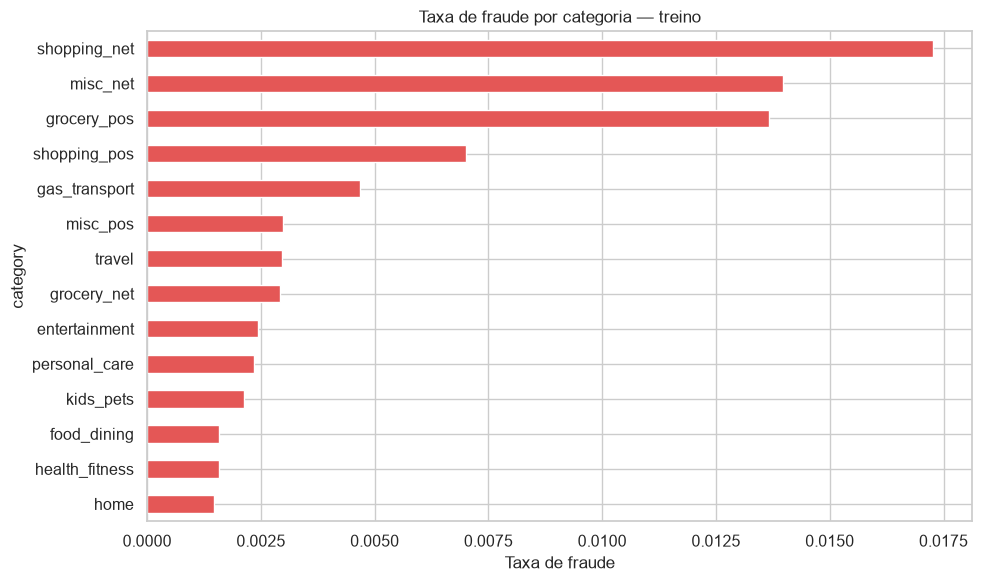

In [90]:
categoria = taxa_por_grupo(df_eda, 'category', top_n=30).sort_values('taxa_fraude')
categoria.taxa_fraude.plot.barh(figsize=(10,6), color='#E45756', title='Taxa de fraude por categoria — treino')
plt.xlabel('Taxa de fraude'); plt.tight_layout(); plt.show()


# <font color='green' style='font-size: 30px;'> 3.3) Variáveis Temporais </font>
<hr style='border: 2px solid green;'>

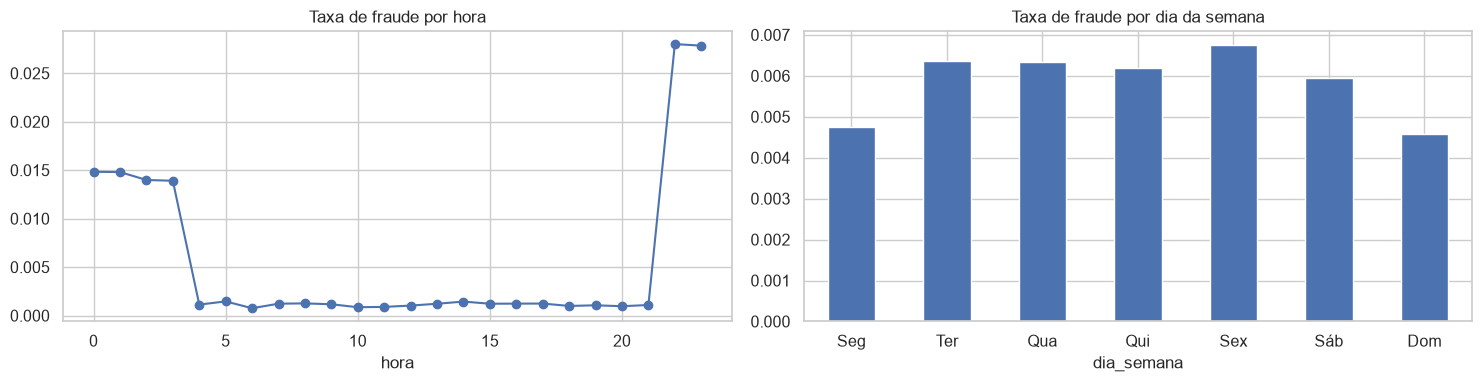

In [91]:
df_eda['hora'] = df_eda.trans_date_trans_time.dt.hour
df_eda['dia_semana'] = df_eda.trans_date_trans_time.dt.dayofweek
fig, ax = plt.subplots(1,2,figsize=(15,4))
df_eda.groupby('hora').is_fraud.mean().plot(marker='o', ax=ax[0], title='Taxa de fraude por hora')
df_eda.groupby('dia_semana').is_fraud.mean().plot.bar(ax=ax[1], title='Taxa de fraude por dia da semana')
ax[1].set_xticklabels(['Seg','Ter','Qua','Qui','Sex','Sáb','Dom'], rotation=0)
plt.tight_layout(); plt.show()


# <font color='orange' style='font-size: 40px;'> 4. Feature Engineering </font>
<hr style='border: 2px solid orange;'>

As features históricas são causais: toda média, contagem e relação usa somente eventos anteriores. O grafo é bipartido entre cartões e lojistas e utiliza graus históricos simples, mantendo interpretação e viabilidade operacional.

In [92]:
df_model = cria_features(df_raw)

# Categóricas nativas do LightGBM. As categorias são harmonizadas entre períodos.
cat_features = ['category','state']
for col in cat_features:
    df_model[col] = df_model[col].astype('category')

display(df_model[['trans_date_trans_time','cc_num','merchant','amt',
                  'qtd_transacoes_cartao_hist','media_amt_cartao_hist',
                  'qtd_transacoes_par_hist','grau_cartao_hist','grau_lojista_hist']].head(10))


,trans_date_trans_time,cc_num,merchant,amt,qtd_transacoes_cartao_hist,media_amt_cartao_hist,qtd_transacoes_par_hist,grau_cartao_hist,grau_lojista_hist
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",4.9700,0,0.0000,0,0,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",107.2300,0,0.0000,0,0,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,220.1100,0,0.0000,0,0,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",45.0000,0,0.0000,0,0,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,41.9600,0,0.0000,0,0,0
5,2019-01-01 00:04:08,4767265376804500,"fraud_Stroman, Hudson and Erdman",94.6300,0,0.0000,0,0,0
6,2019-01-01 00:04:42,30074693890476,fraud_Rowe-Vandervort,44.5400,0,0.0000,0,0,0
7,2019-01-01 00:05:08,6011360759745864,fraud_Corwin-Collins,71.6500,0,0.0000,0,0,0
8,2019-01-01 00:05:18,4922710831011201,fraud_Herzog Ltd,4.2700,0,0.0000,0,0,0
9,2019-01-01 00:06:01,2720830304681674,"fraud_Schoen, Kuphal and Nitzsche",198.3900,0,0.0000,0,0,0


In [93]:
# Testes de causalidade básicos.
primeira_cartao = df_model.groupby('cc_num', observed=True).head(1)
primeira_par = df_model.groupby(['cc_num','merchant'], observed=True).head(1)
assert primeira_cartao.qtd_transacoes_cartao_hist.eq(0).all()
assert primeira_par.qtd_transacoes_par_hist.eq(0).all()
assert df_model[['grau_cartao_hist','grau_lojista_hist','qtd_transacoes_par_hist']].ge(0).all().all()
print('Auditoria causal aprovada.')


Auditoria causal aprovada.


# <font color='orange' style='font-size: 40px;'> 5. Modelagem </font>
<hr style='border: 2px solid orange;'>

# <font color='green' style='font-size: 30px;'> 5.1) Métricas </font>
<hr style='border: 2px solid green;'>

### Métricas principais

**Gini** mede ordenação e será nossa referência visual:

\[
Gini = 2\,AUC - 1
\]

Gini próximo de zero indica ranking aleatório; quanto mais próximo de um, melhor a separação.

**PR-AUC** resume precision e recall quando a fraude é rara. **Precision** responde quantos alertas eram fraude. **Recall** responde quantas fraudes foram capturadas. **Alert Rate** mostra o tamanho da fila operacional.

O Gini pode parecer alto mesmo com uma fila pouco eficiente em classes extremamente raras; por isso ele será lido junto com PR-AUC, precision e recall.

# <font color='green' style='font-size: 30px;'> 5.2) Features e Pré-processamento </font>
<hr style='border: 2px solid green;'>

O LightGBM não exige escalonamento. Variáveis categóricas serão tratadas nativamente. Identificadores, PII, target e campos redundantes são removidos por decisão de negócio e prevenção de leakage.

In [94]:
features = [
    'amt','log_amt','category','state','city_pop',
    'idade','hora','dia_semana','fim_semana','hora_sin','hora_cos',
    'distancia_cliente_lojista_km','qtd_transacoes_cartao_hist',
    'segundos_ultima_transacao','media_amt_cartao_hist','std_amt_cartao_hist',
    'zscore_amt_cartao','freq_transacoes_cartao_dia','qtd_transacoes_lojista_hist',
    'media_amt_lojista_hist','std_amt_lojista_hist','qtd_transacoes_par_hist',
    'grau_cartao_hist','grau_lojista_hist','novo_par_cartao_lojista',
    'participacao_lojista_cartao']

amostras = {nome: df_model.loc[df_model.amostra.eq(nome)].copy()
            for nome in ['Treino','Validacao','Calibracao','Politica','Teste','OOT']}
x_train, y_train = amostras['Treino'][features], amostras['Treino'].is_fraud
x_valid, y_valid = amostras['Validacao'][features], amostras['Validacao'].is_fraud
print(x_train.shape, x_valid.shape, f'| {len(features)} features')


(924850, 26) (172843, 26) | 26 features


# <font color='green' style='font-size: 30px;'> 5.3) LightGBM Benchmark </font>
<hr style='border: 2px solid green;'>

O benchmark é deliberadamente conservador. O objetivo não é maximizar o treino, mas estabelecer uma referência temporal com regularização.

In [95]:
lgbm_benchmark = modelo_lightgbm()
lgbm_benchmark.fit(x_train, y_train, categorical_feature='auto')
p_train_base = lgbm_benchmark.predict_proba(x_train)[:,1]
p_valid_base = lgbm_benchmark.predict_proba(x_valid)[:,1]

metricas_benchmark = pd.concat([
    metricas_modelo('LightGBM Benchmark','Treino',y_train,p_train_base),
    metricas_modelo('LightGBM Benchmark','Validacao',y_valid,p_valid_base)])
metricas_benchmark['Gap_Gini_vs_Validacao'] = metricas_benchmark.Gini.iloc[0]-metricas_benchmark.Gini.iloc[1]
display(metricas_benchmark)


,Modelo,Etapa,Gini,PR_AUC,Taxa_Fraude,Gap_Gini_vs_Validacao
0,LightGBM Benchmark,Treino,0.9947,0.8996,0.0056,0.0021
0,LightGBM Benchmark,Validacao,0.9926,0.8801,0.0065,0.0021


# <font color='green' style='font-size: 30px;'> 5.4) HyperOpt e Controle de Overfitting </font>
<hr style='border: 2px solid green;'>

O HyperOpt maximiza PR-AUC na validação e penaliza simultaneamente gaps excessivos de Gini e PR-AUC. O Gini pode saturar próximo de 1 mesmo quando a precisão do ranking raro ainda está overfittada; por isso o gap de PR-AUC recebe penalização maior. Teste e OOT não entram na busca.

In [96]:
model_otimizado, best_hiperpams, trials = otimizacao_hyperopt(
    x_train, y_train, x_valid, y_valid, max_evals=20)
display(pd.DataFrame([best_hiperpams]))

p_train_opt = model_otimizado.predict_proba(x_train)[:,1]
p_valid_opt = model_otimizado.predict_proba(x_valid)[:,1]
metricas_otimizadas = pd.concat([
    metricas_modelo('LightGBM + HyperOpt','Treino',y_train,p_train_opt),
    metricas_modelo('LightGBM + HyperOpt','Validacao',y_valid,p_valid_opt)])
display(pd.concat([metricas_benchmark, metricas_otimizadas], ignore_index=True))
print(f'Gap de Gini otimizado: {(metricas_otimizadas.Gini.iloc[0]-metricas_otimizadas.Gini.iloc[1]):.4f}')
print(f'Gap de PR-AUC otimizado: {(metricas_otimizadas.PR_AUC.iloc[0]-metricas_otimizadas.PR_AUC.iloc[1]):.4f}')


100%|██████████| 20/20 [06:10<00:00, 18.53s/trial, best loss: -0.9053401997061634]


,colsample_bytree,learning_rate,max_depth,min_child_samples,n_estimators,num_leaves,reg_alpha,reg_lambda,subsample
0,0.8036,0.0268,5,400,350,20,0.4144,0.5920,0.6621


,Modelo,Etapa,Gini,PR_AUC,Taxa_Fraude,Gap_Gini_vs_Validacao
0,LightGBM Benchmark,Treino,0.9947,0.8996,0.0056,0.0021
1,LightGBM Benchmark,Validacao,0.9926,0.8801,0.0065,0.0021
2,LightGBM + HyperOpt,Treino,0.9982,0.9481,0.0056,NaN
3,LightGBM + HyperOpt,Validacao,0.9955,0.9053,0.0065,NaN


Gap de Gini otimizado: 0.0027
Gap de PR-AUC otimizado: 0.0428


In [97]:
historico_hyperopt = pd.DataFrame([{k:v for k,v in r.items() if k!='status'} for r in trials.results])
display(historico_hyperopt.sort_values('loss').head(10))


,loss,ap_valid,ap_train,gap_ap,gini_train,gini_valid
10,-0.9053,0.9053,0.9481,0.0428,0.9982,0.9955
8,-0.9036,0.9036,0.9613,0.0578,0.9988,0.9952
15,-0.8994,0.8994,0.9498,0.0505,0.9982,0.9946
13,-0.8952,0.8952,0.9410,0.0458,0.9979,0.9948
5,-0.8907,0.8907,0.9629,0.0722,0.9991,0.9947
18,-0.8861,0.8861,0.9219,0.0358,0.9965,0.9932
11,-0.8854,0.8854,0.9229,0.0375,0.9969,0.9943
2,-0.8807,0.8807,0.9099,0.0292,0.9957,0.9934
0,-0.8787,0.8787,0.8999,0.0212,0.9943,0.9916
4,-0.8773,0.8773,0.9133,0.0360,0.9963,0.9929


# <font color='green' style='font-size: 30px;'> 5.5) SHAP </font>
<hr style='border: 2px solid green;'>

SHAP mostra quanto cada variável deslocou o score do modelo. Ele explica associação no modelo, não causalidade.

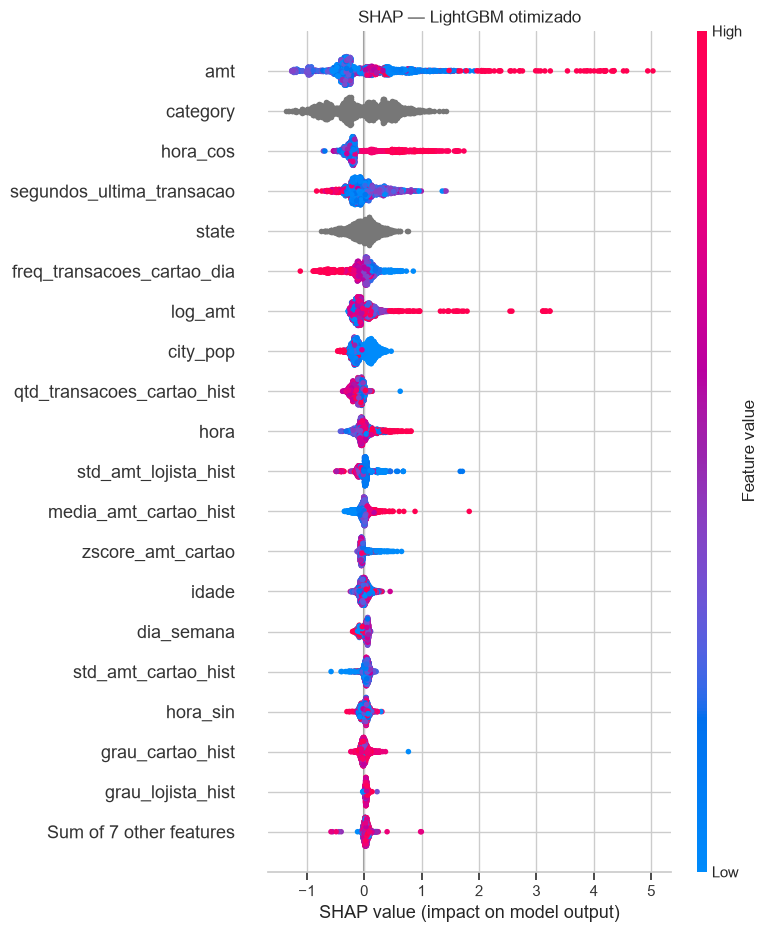

In [98]:
amostra_shap = x_valid.sample(min(2000,len(x_valid)), random_state=RANDOM_STATE)
explainer, shap_values = plot_shap(model_otimizado, amostra_shap, 'SHAP — LightGBM otimizado')


# <font color='green' style='font-size: 30px;'> 5.6) Calibração do Score Supervisionado </font>
<hr style='border: 2px solid green;'>

Gini e PR-AUC avaliam ranking; calibração responde se uma estimativa de 10% corresponde, aproximadamente, a 10% de fraude observada.

Apesar de o LightGBM produzir valores entre 0 e 1, esses valores não são necessariamente probabilidades bem calibradas. Abril ajusta os calibradores; maio compara isotônica e sigmoide por Brier Score. O vencedor é reajustado em abril e maio, sem utilizar junho, teste ou OOT.

In [99]:
df_cal = amostras['Calibracao']
mask_abril = df_cal.trans_date_trans_time.dt.month.eq(4).to_numpy()
score_cal_supervisionado = model_otimizado.predict_proba(df_cal[features])[:,1]
y_cal_fit = df_cal.loc[mask_abril,'is_fraud']
y_cal_eval = df_cal.loc[~mask_abril,'is_fraud']

calibradores = {}
comparacao_calibracao = []
for metodo in ['sigmoid','isotonic']:
    cal = ajusta_calibrador_score(score_cal_supervisionado[mask_abril],y_cal_fit,metodo)
    p = prediz_calibrador(cal,score_cal_supervisionado[~mask_abril],metodo)
    calibradores[metodo] = cal
    comparacao_calibracao.append({'Metodo':metodo,
                                  'Brier':brier_score_loss(y_cal_eval,p),
                                  'LogLoss':log_loss(y_cal_eval,np.clip(p,1e-8,1-1e-8))})
comparacao_calibracao = pd.DataFrame(comparacao_calibracao).sort_values('Brier')
display(comparacao_calibracao)
metodo_calibracao = comparacao_calibracao.iloc[0].Metodo
modelo_calibrado = ajusta_calibrador_score(score_cal_supervisionado,df_cal.is_fraud,metodo_calibracao)
print('Método escolhido:', metodo_calibracao)


,Metodo,Brier,LogLoss
1,isotonic,0.0014,0.0056
0,sigmoid,0.0018,0.0096


Método escolhido: isotonic


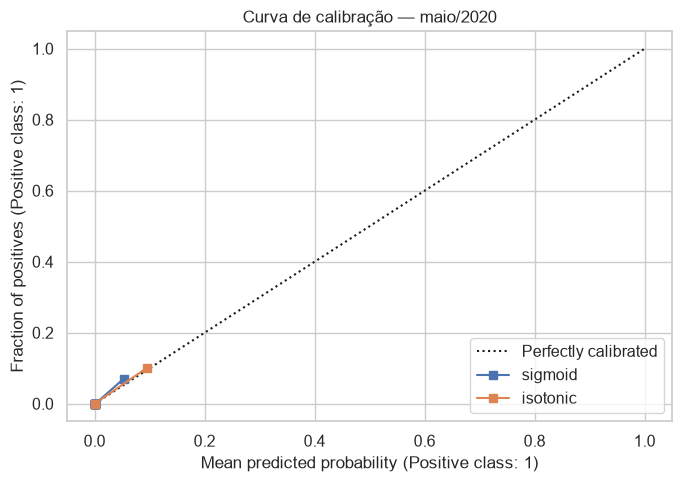

In [100]:
fig, ax = plt.subplots(figsize=(7,5))
for metodo, cal in calibradores.items():
    CalibrationDisplay.from_predictions(y_cal_eval,
                                        prediz_calibrador(cal,score_cal_supervisionado[~mask_abril],metodo),
                                        n_bins=10, strategy='quantile', name=metodo, ax=ax)
ax.set_title('Curva de calibração — maio/2020'); plt.tight_layout(); plt.show()


# <font color='green' style='font-size: 30px;'> 5.7) Cutoff, Rating e Política </font>
<hr style='border: 2px solid green;'>

O score supervisionado ordena a fila; a probabilidade calibrada estima risco. O cutoff é escolhido apenas em junho, com limite inicial de 1% das transações para revisão.

O Rating divide o risco relativo em cinco faixas congeladas na amostra de política: `A` representa menor risco e `E`, maior risco. Rating não é uma nova target; é uma tradução operacional do ranking.

O benefício financeiro é ilustrativo: fraude capturada evita o valor, fraude perdida perde o valor e cada alerta gera custo de revisão e possível atrito. Os valores devem ser substituídos por dados reais antes de produção.

Alerta (Alert Rate): Um alerta é uma transação cujo risco estimado ultrapassou o cutoff operacional e, por isso, foi encaminhada para alguma ação, como revisão manual, autenticação adicional ou bloqueio. O Alert Rate representa a proporção de todas as transações que geram alerta. Por exemplo, um Alert Rate de 1% significa que, a cada 100 mil transações, aproximadamente mil exigirão alguma ação. Essa métrica traduz o resultado do modelo em carga operacional: aumentar o número de alertas tende a capturar mais fraudes, mas também eleva o custo e a quantidade de clientes legítimos impactados.

Capacidade: Capacidade é o volume máximo de transações que a operação consegue analisar ou tratar em determinado período. Ela pode ser expressa como quantidade de alertas ou percentual do total de transações. Como não é possível revisar todas as operações, a capacidade limita o cutoff que pode ser utilizado: o modelo deve ordenar as transações pelo risco, permitindo que a equipe concentre seus recursos nos casos mais suspeitos. Assim, a análise de capacidade mostra quantas fraudes seriam encontradas e qual seria a precisão caso fossem investigados, por exemplo, apenas os 0,5%, 1% ou 2% de maior risco.

In [101]:
df_politica = amostras['Politica']
x_politica, y_politica = df_politica[features], df_politica.is_fraud
score_politica = model_otimizado.predict_proba(x_politica)[:,1]
prob_politica = prediz_calibrador(modelo_calibrado,score_politica,metodo_calibracao)

display(tabela_capacidade(y_politica, score_politica))
cutoff_score, curva_cutoff = escolhe_cutoff_politica(
    df_politica, score_politica, capacidade_max=.01,
    taxa_recuperacao=.75, custo_revisao=2, custo_atrito_fp=5)
print('Cutoff de score escolhido:', round(cutoff_score,6))
display(metricas_modelo('LGBM + Calibração + Política','Politica',
                         y_politica,score_politica,cutoff_score))

cortes_rating = np.quantile(score_politica,[.80,.95,.99,.995])
rating_politica = cria_rating(score_politica,cortes_rating)
display(pd.DataFrame({'Rating':rating_politica,'Fraude':y_politica})
        .groupby('Rating',observed=True).Fraude.agg(Transacoes='size',Fraudes='sum',Taxa_Fraude='mean'))


,Capacidade,Alertas,Precisao,Recall,Cutoff_Score
0,0.0010,58,1.0000,0.1737,0.9662
1,0.0025,145,1.0000,0.4341,0.8891
2,0.0050,289,0.8651,0.7485,0.2145
3,0.0100,578,0.5087,0.8802,0.0325
4,0.0200,1155,0.2771,0.9581,0.0099


Cutoff de score escolhido: 0.036098


,Modelo,Etapa,Gini,PR_AUC,Taxa_Fraude,Cutoff,Precisao,Recall,F1,Alert_Rate
0,LGBM + Calibração + Política,Politica,0.9947,0.8732,0.0058,0.0361,0.5385,0.8802,0.6682,0.0095


,Transacoes,Fraudes,Taxa_Fraude
Rating,,,
A,46197,0,0.0000
B,8662,4,0.0005
C,2310,36,0.0156
D,289,44,0.1522
E,289,250,0.8651


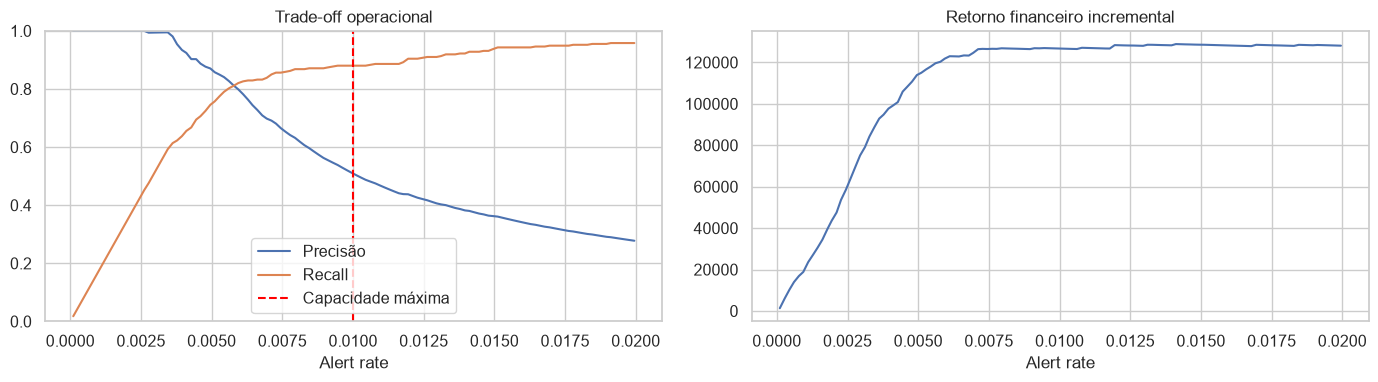

In [102]:
curva_elegivel = curva_cutoff[curva_cutoff.alert_rate <= .02].sort_values('alert_rate')
fig, ax = plt.subplots(1,2,figsize=(14,4))
ax[0].plot(curva_elegivel.alert_rate, curva_elegivel.precision, label='Precisão')
ax[0].plot(curva_elegivel.alert_rate, curva_elegivel.recall, label='Recall')
ax[0].axvline(.01,color='red',ls='--',label='Capacidade máxima'); ax[0].legend()
ax[0].set(xlabel='Alert rate',title='Trade-off operacional')
ax[0].set_ylim(0,1)
ax[1].plot(curva_elegivel.alert_rate, curva_elegivel.retorno_incremental)
ax[1].set(xlabel='Alert rate',title='Retorno financeiro incremental')
plt.tight_layout(); plt.show()


# <font color='green' style='font-size: 30px;'> 5.8) Teste, OOT e Estabilidade Temporal </font>
<hr style='border: 2px solid green;'>

Todas as decisões estão congeladas. Agora comparamos Treino, Validação, Teste e OOT com o mesmo modelo, cutoff e cortes de Rating. Treino é uma visão otimista; validação participou do HyperOpt; teste e OOT são as evidências finais.

Além da estabilidade isolada, confrontamos cada métrica com a prevalência mensal. O eixo da métrica permanece fixo entre 0 e 1; a prevalência usa um segundo eixo em percentual porque sua ordem de grandeza é inferior a 1%.

In [103]:
resultados = []
scores_finais = {}
probs_finais = {}
ratings_finais = {}
for etapa in ['Teste','OOT']:
    d = amostras[etapa]
    score = model_otimizado.predict_proba(d[features])[:,1]
    prob = prediz_calibrador(modelo_calibrado,score,metodo_calibracao)
    scores_finais[etapa], probs_finais[etapa] = score, prob
scores_comparacao = {
    'Treino':p_train_opt,
    'Validacao':p_valid_opt,
    'Teste':scores_finais['Teste'],
    'OOT':scores_finais['OOT']}

for etapa,score in scores_comparacao.items():
    ratings_finais[etapa] = cria_rating(score,cortes_rating)
    resultados.append(metricas_modelo(
        'LightGBM Supervisionado',etapa,amostras[etapa].is_fraud,score,cutoff_score))

metricas_finais = pd.concat(resultados, ignore_index=True)
display(metricas_finais[['Modelo','Etapa','Gini','PR_AUC','Taxa_Fraude',
                          'Precisao','Recall','F1','Alert_Rate','Cutoff']])


,Modelo,Etapa,Gini,PR_AUC,Taxa_Fraude,Precisao,Recall,F1,Alert_Rate,Cutoff
0,LightGBM Supervisionado,Treino,0.9982,0.9481,0.0056,0.4933,0.9680,0.6535,0.0111,0.0361
1,LightGBM Supervisionado,Validacao,0.9955,0.9053,0.0065,0.5654,0.9127,0.6982,0.0105,0.0361
2,LightGBM Supervisionado,Teste,0.9925,0.8499,0.0044,0.4668,0.8784,0.6096,0.0083,0.0361
3,LightGBM Supervisionado,OOT,0.9899,0.8604,0.0033,0.3986,0.9028,0.5530,0.0075,0.0361


,Etapa,Rating,Transacoes,Distribuicao,Fraudes,Taxa_Fraude
0,Treino,A,726068,0.7851,0,0.0000
1,Treino,B,147643,0.1596,11,0.0001
2,Treino,C,40371,0.0437,149,0.0037
3,Treino,D,5271,0.0057,358,0.0679
4,Treino,E,5497,0.0059,4702,0.8554
5,Validacao,A,137342,0.7946,0,0.0000
6,Validacao,B,26418,0.1528,10,0.0004
7,Validacao,C,7168,0.0415,83,0.0116
8,Validacao,D,893,0.0052,121,0.1355
9,Validacao,E,1022,0.0059,909,0.8894


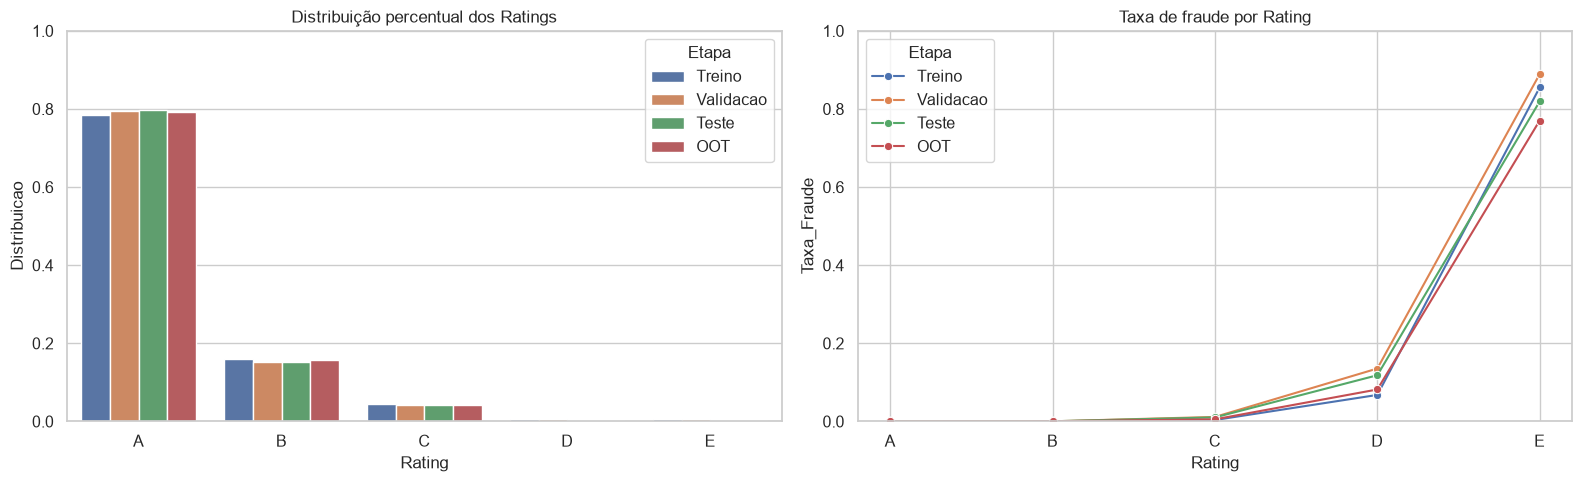

In [104]:
tabelas_rating = []
for etapa in ['Treino','Validacao','Teste','OOT']:
    tabela_rating = pd.DataFrame({'Rating':ratings_finais[etapa],
                                  'Fraude':amostras[etapa].is_fraud.to_numpy()})
    resumo = (tabela_rating.groupby('Rating',observed=True).Fraude
              .agg(Transacoes='size',Fraudes='sum',Taxa_Fraude='mean').reset_index())
    resumo['Distribuicao'] = resumo.Transacoes/resumo.Transacoes.sum()
    resumo['Etapa'] = etapa
    tabelas_rating.append(resumo)

comparacao_rating = pd.concat(tabelas_rating,ignore_index=True)
display(comparacao_rating[['Etapa','Rating','Transacoes','Distribuicao','Fraudes','Taxa_Fraude']])

fig,ax = plt.subplots(1,2,figsize=(16,5))
sns.barplot(data=comparacao_rating,x='Rating',y='Distribuicao',hue='Etapa',ax=ax[0])
ax[0].set_ylim(0,1); ax[0].set_title('Distribuição percentual dos Ratings')
sns.lineplot(data=comparacao_rating,x='Rating',y='Taxa_Fraude',hue='Etapa',
             marker='o',ax=ax[1])
ax[1].set_ylim(0,1); ax[1].set_title('Taxa de fraude por Rating')
plt.tight_layout(); plt.show()


In [105]:
for etapa in ['Treino','Validacao','Teste','OOT']:
    print(f'\nCapacidade — {etapa}')
    display(tabela_capacidade(amostras[etapa].is_fraud, scores_comparacao[etapa]))



Capacidade — Treino


,Capacidade,Alertas,Precisao,Recall,Cutoff_Score
0,0.0010,925,1.0000,0.1772,0.9870
1,0.0025,2313,1.0000,0.4431,0.9455
2,0.0050,4625,0.9449,0.8372,0.4205
3,0.0100,9249,0.5441,0.9640,0.0453
4,0.0200,18497,0.2770,0.9816,0.0117



Capacidade — Validacao


,Capacidade,Alertas,Precisao,Recall,Cutoff_Score
0,0.0010,173,1.0000,0.1541,0.9779
1,0.0025,433,1.0000,0.3856,0.9244
2,0.0050,865,0.9457,0.7284,0.3849
3,0.0100,1729,0.5905,0.9092,0.0409
4,0.0200,3457,0.3110,0.9573,0.0106



Capacidade — Teste


,Capacidade,Alertas,Precisao,Recall,Cutoff_Score
0,0.0010,275,1.0000,0.2275,0.9555
1,0.0025,686,0.9767,0.5542,0.7041
2,0.0050,1371,0.7155,0.8114,0.1145
3,0.0100,2742,0.3946,0.8950,0.0267
4,0.0200,5484,0.2092,0.9487,0.0086



Capacidade — OOT


,Capacidade,Alertas,Precisao,Recall,Cutoff_Score
0,0.0010,282,0.9965,0.3002,0.9508
1,0.0025,704,0.9261,0.6966,0.4961
2,0.0050,1408,0.5760,0.8665,0.0816
3,0.0100,2816,0.3047,0.9167,0.0225
4,0.0200,5631,0.1579,0.9498,0.0083


,Mes,N,Taxa_Fraude,Gini,PR_AUC,Precisao,Recall,Alert_Rate
0,2020-06,87805,0.0053,0.9949,0.8693,0.5187,0.8908,0.0091
1,2020-07,85848,0.0037,0.9926,0.8617,0.4414,0.8910,0.0075
2,2020-08,88759,0.0047,0.9892,0.8194,0.4709,0.8386,0.0083
3,2020-09,69533,0.0049,0.9951,0.8731,0.4842,0.9000,0.0091
4,2020-10,69348,0.0055,0.9887,0.8780,0.5375,0.8958,0.0092
5,2020-11,72635,0.0040,0.9926,0.9045,0.4676,0.9320,0.0081
6,2020-12,139538,0.0018,0.9884,0.7940,0.2539,0.8798,0.0064


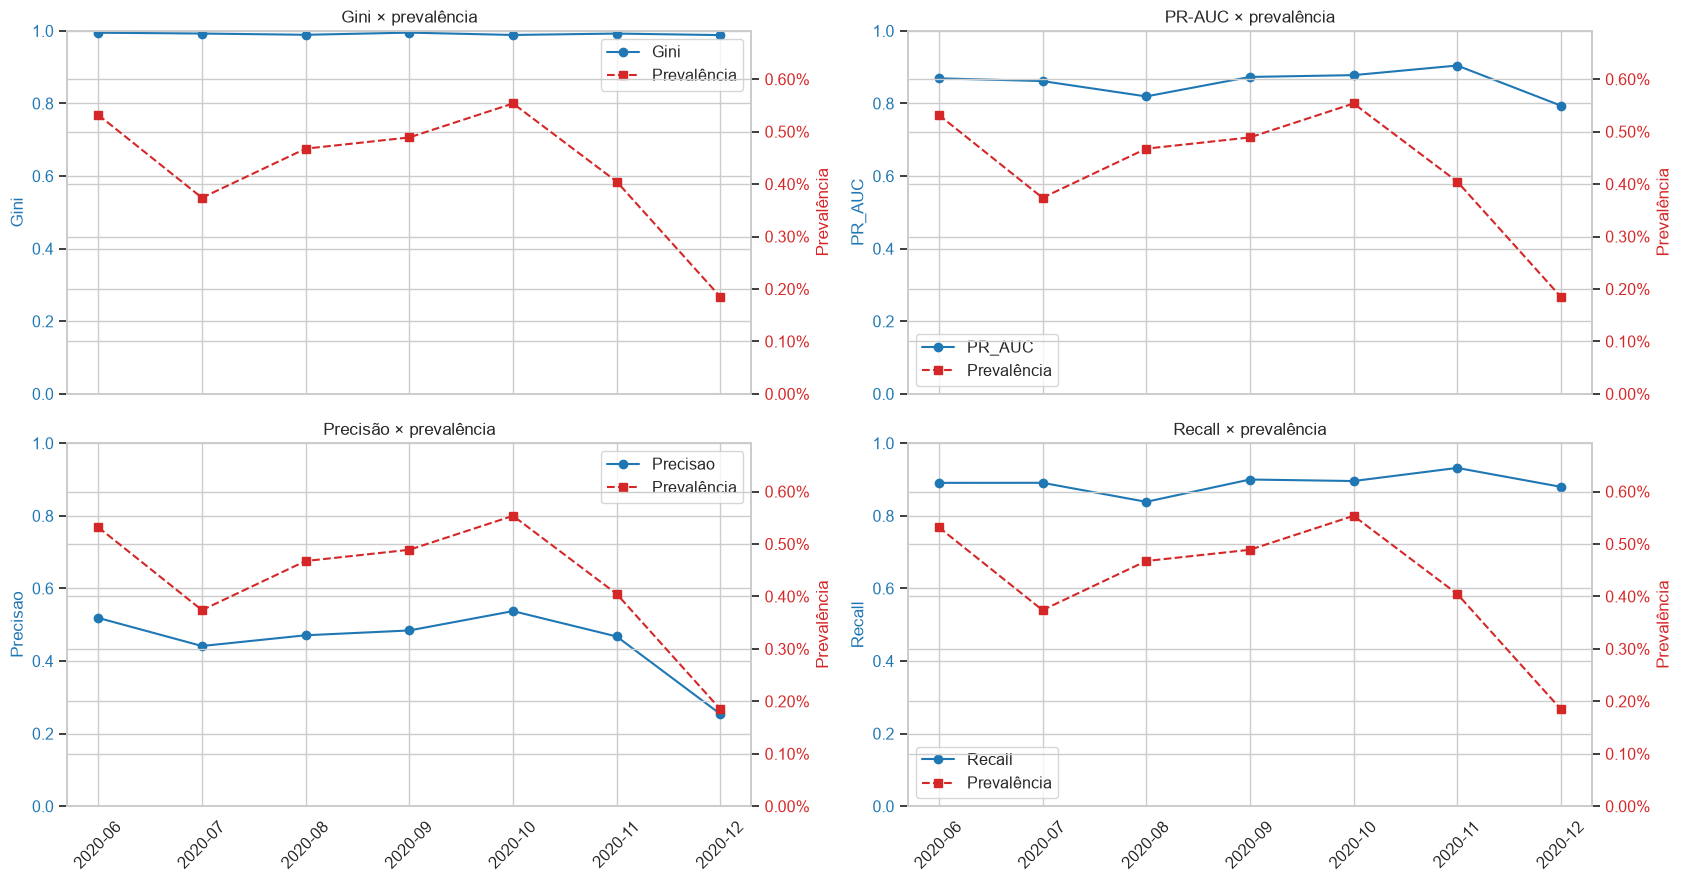

In [110]:
df_avaliacao = pd.concat([amostras['Politica'],amostras['Teste'],amostras['OOT']])
score_avaliacao = np.concatenate([score_politica,scores_finais['Teste'],scores_finais['OOT']])
estabilidade = metricas_mensais(df_avaliacao, score_avaliacao, cutoff_score)
display(estabilidade)

# Relação temporal entre prevalência e desempenho.
fig, ax = plt.subplots(2,2,figsize=(17,9),sharex=True)
for eixo, metrica, titulo in zip(
        ax.ravel(),
        ['Gini','PR_AUC','Precisao','Recall'],
        ['Gini × prevalência','PR-AUC × prevalência',
         'Precisão × prevalência','Recall × prevalência']):
    linha_metrica = eixo.plot(estabilidade.Mes,estabilidade[metrica],
                              marker='o',color='#1F77B4',label=metrica)
    eixo.set_ylim(0,1)
    eixo.set_ylabel(metrica,color='#1F77B4')
    eixo.tick_params(axis='y',labelcolor='#1F77B4')
    eixo.tick_params(axis='x',rotation=45)
    eixo.set_title(titulo)

    eixo_prev = eixo.twinx()
    linha_prev = eixo_prev.plot(estabilidade.Mes,estabilidade.Taxa_Fraude,
                                marker='s',ls='--',color='#D62728',label='Prevalência')
    limite_prev = max(estabilidade.Taxa_Fraude.max()*1.25,.001)
    eixo_prev.set_ylim(0,limite_prev)
    eixo_prev.yaxis.set_major_formatter(PercentFormatter(1.0))
    eixo_prev.set_ylabel('Prevalência',color='#D62728')
    eixo_prev.tick_params(axis='y',labelcolor='#D62728')
    eixo.legend(linha_metrica+linha_prev,
                [l.get_label() for l in linha_metrica+linha_prev],loc='best')
plt.tight_layout(); plt.show()


# <font color='green' style='font-size: 30px;'> 5.9) Retorno Financeiro </font>
<hr style='border: 2px solid green;'>

O retorno é calculado contra o cenário-base de aprovar tudo. Para cada período:

\[
Retorno\ incremental = Fraude\ evitada - Custo\ de\ revisão - Custo\ de\ atrito
\]

Premissas centrais: recuperação de 75% do valor alertado, custo de revisão de R$ 2 e custo médio de atrito de R$ 5 por falso positivo. Como a base não fornece esses valores, mostramos sensibilidade; o número não deve ser tratado como previsão contábil.

In [108]:
financeiro = []
for etapa in ['Teste','OOT']:
    pred = scores_finais[etapa] >= cutoff_score
    linha = retorno_financeiro_incremental(amostras[etapa],pred,
                                           taxa_recuperacao=.75,
                                           custo_revisao=2,custo_atrito_fp=5)
    linha['Etapa'] = etapa
    financeiro.append(linha)
display(pd.DataFrame(financeiro).set_index('Etapa'))

sensibilidade = []
for recuperacao in [.50,.75,1.00]:
    for atrito in [1,5,10]:
        valor = retorno_financeiro_incremental(
            amostras['Teste'],scores_finais['Teste']>=cutoff_score,
            taxa_recuperacao=recuperacao,custo_revisao=2,custo_atrito_fp=atrito)
        sensibilidade.append({'Taxa_Recuperacao':recuperacao,
                              'Custo_Atrito_FP':atrito,
                              'Retorno_Teste':valor['Retorno_incremental']})
display(pd.DataFrame(sensibilidade).pivot(index='Taxa_Recuperacao',
                                          columns='Custo_Atrito_FP',values='Retorno_Teste'))


,Perda_sem_modelo,Fraude_evitada,Custo_revisao_atrito,Retorno_incremental
Etapa,,,,
Teste,"643,430.8400","467,273.1300",10615,"456,658.1300"
OOT,"489,893.8400","358,831.4175",10615,"348,216.4175"


Custo_Atrito_FP,1,5,10
Taxa_Recuperacao,,,
0.5000,"305,752.4200","300,900.4200","294,835.4200"
0.7500,"461,510.1300","456,658.1300","450,593.1300"
1.0000,"617,267.8400","612,415.8400","606,350.8400"


# <font color='orange' style='font-size: 40px;'> 6. Conclusões </font>
<hr style='border: 2px solid orange;'>

O modelo deve ser julgado pelo conjunto de evidências:

1. Gap de Gini **e de PR-AUC** entre treino e validação.
2. Estabilidade de Gini e PR-AUC em teste e OOT.
3. Precision e recall dentro da capacidade operacional.
4. Alert rate ao longo do tempo, sempre com escala gráfica de 0 a 1.
5. Calibração das probabilidades e monotonicidade do Rating.
6. Coerência das explicações SHAP.
7. Retorno incremental positivo sob diferentes premissas.

`merchant`, `gender` e `job` não entram no classificador. O primeiro é usado somente como chave técnica para construir relações históricas; `gender` é excluído por governança; `job` é removido porque seu IV excessivo revelou separação artificial e categorias esparsas no simulador.

Como a base é simulada, custos, atraso de confirmação e padrões adversariais reais não estão representados. O projeto demonstra uma metodologia, não uma promessa de performance em produção.

In [109]:
artefato = {
    'modelo_ranking':model_otimizado,
    'modelo_calibrado':modelo_calibrado,
    'features':features,
    'categoricas':cat_features,
    'cutoff_score_revisao':cutoff_score,
    'cortes_rating':cortes_rating,
    'metodo_calibracao':metodo_calibracao,
    'target':'is_fraud',
    'periodos':{'treino':'2019','validacao':'2020-01 a 2020-03',
                'calibracao':'2020-04 a 2020-05','politica':'2020-06',
                'teste':'2020-06 a 2020-09','oot':'2020-10 a 2020-12'}}
joblib.dump(artefato, './models/modelo_fraude_sparkov.pkl')
print('Artefato salvo em models/modelo_fraude_sparkov.pkl')


Artefato salvo em models/modelo_fraude_sparkov.pkl
